In [1]:
from utils import get_svamp_df
from statistical_significance import compare_accuracies, compare_accuracies_v2, compare_accuracies_v3
import numpy as np
df = get_svamp_df("Direct Prompting")

gemma-3-27b-it.xlsx
qwen3_1.7b.xlsx
smollm2_360m.xlsx
Error processing ./ollama/smollm2_360m.xlsx: Worksheet named 'Error-Analysis' not found
qwen2-math_1.5b.xlsx
qwen3_0.6b.xlsx
qwen2.5_0.5b.xlsx
gemma3_1b.xlsx
deepseek-r1_1.5b.xlsx
llama3.2_1b.xlsx
smollm2_1.7b.xlsx


# Misclassified

In [2]:
df_misc = get_svamp_df("Direct Prompting", include_misclassified=True)
df_misc = df_misc[df_misc["Error Type"] == "Misclassified"]
df_misc.groupby(["Model", "Error Class"]).agg({
    "ID": "count",
}).reset_index().sort_values(by="ID", ascending=False).head(50)

gemma-3-27b-it.xlsx
qwen3_1.7b.xlsx
smollm2_360m.xlsx
Error processing ./ollama/smollm2_360m.xlsx: Worksheet named 'Error-Analysis' not found
qwen2-math_1.5b.xlsx
qwen3_0.6b.xlsx
qwen2.5_0.5b.xlsx
gemma3_1b.xlsx
deepseek-r1_1.5b.xlsx
llama3.2_1b.xlsx
smollm2_1.7b.xlsx


,Model,Error Class,ID
1,ollama/deepseek-r1_1.5b,Misclassified,11
3,ollama/llama3.2_1b,Misclassified,9
5,ollama/qwen2.5_0.5b,Misclassified,8
4,ollama/qwen2-math_1.5b,Misclassified,5
0,google/gemma-3-27b-it,Misclassified,4
7,ollama/smollm2_1.7b,Misclassified,4
6,ollama/qwen3_1.7b,Misclassified,3
2,ollama/gemma3_1b,Misclassified,1


In [3]:
overall_misc_rate = len(df_misc) / len(df)
print(f"Total misclassified examples: {len(df_misc)}")
print(f"Total examples: {len(df)}")
print(f"Overall misclassification rate: {overall_misc_rate:.2%}")

Total misclassified examples: 45
Total examples: 2556
Overall misclassification rate: 1.76%


# Accuracy

## Sorted

In [4]:
df_acc = df.groupby(["Model"]).agg({
    "is_correct": "mean",
}).reset_index().sort_values(by="is_correct", ascending=False)
df_acc

,Model,is_correct
0,google/gemma-3-27b-it,0.989437
4,ollama/qwen2-math_1.5b,0.93662
1,ollama/deepseek-r1_1.5b,0.834507
7,ollama/qwen3_1.7b,0.823944
6,ollama/qwen3_0.6b,0.757042
2,ollama/gemma3_1b,0.693662
3,ollama/llama3.2_1b,0.683099
8,ollama/smollm2_1.7b,0.580986
5,ollama/qwen2.5_0.5b,0.566901


## Alphabetical

In [5]:
df_acc = df.groupby(["Model"]).agg({
    "is_correct": "mean",
}).reset_index().sort_values(by="Model", ascending=True)
df_acc

,Model,is_correct
0,google/gemma-3-27b-it,0.989437
1,ollama/deepseek-r1_1.5b,0.834507
2,ollama/gemma3_1b,0.693662
3,ollama/llama3.2_1b,0.683099
4,ollama/qwen2-math_1.5b,0.93662
5,ollama/qwen2.5_0.5b,0.566901
6,ollama/qwen3_0.6b,0.757042
7,ollama/qwen3_1.7b,0.823944
8,ollama/smollm2_1.7b,0.580986


# Error Analysis

## Overview

In [6]:
df_err = df.groupby(["Model", "Error Type", "Error Class"]).agg({
    "ID": "count",
}).pivot_table(
    index=["Model"],
    columns=["Error Type", "Error Class"],
    values="ID",
    fill_value=0
).reset_index()

df_err.head(50)

Error Type                     Model   Execution Error                     \
Error Class                          Calculation Error Declines to Answer   
0              google/gemma-3-27b-it               0.0                0.0   
1            ollama/deepseek-r1_1.5b               4.0                0.0   
2                   ollama/gemma3_1b               2.0                0.0   
3                 ollama/llama3.2_1b              11.0                0.0   
4             ollama/qwen2-math_1.5b               2.0                0.0   
5                ollama/qwen2.5_0.5b               9.0                0.0   
6                  ollama/qwen3_0.6b               2.0                0.0   
7                  ollama/qwen3_1.7b               0.0                0.0   
8                ollama/smollm2_1.7b              10.0                1.0   

Error Type                                                     
Error Class  Loop Overthinking Too Few Tokens Wrong Reasoning  
0             0.0          1.0            0.0             2.0  
1             3.0          0.0            0.0            40.0  
2            53.0          6.0            0.0            26.0  
3             0.0          0.0            0.0            79.0  
4             0.0          0.0            0.0            16.0  
5             0.0          0.0            0.0           114.0  
6             0.0         53.0            1.0            13.0  
7             5.0         32.0           13.0             0.0  
8             1.0          0.0            0.0           107.0

## Plots

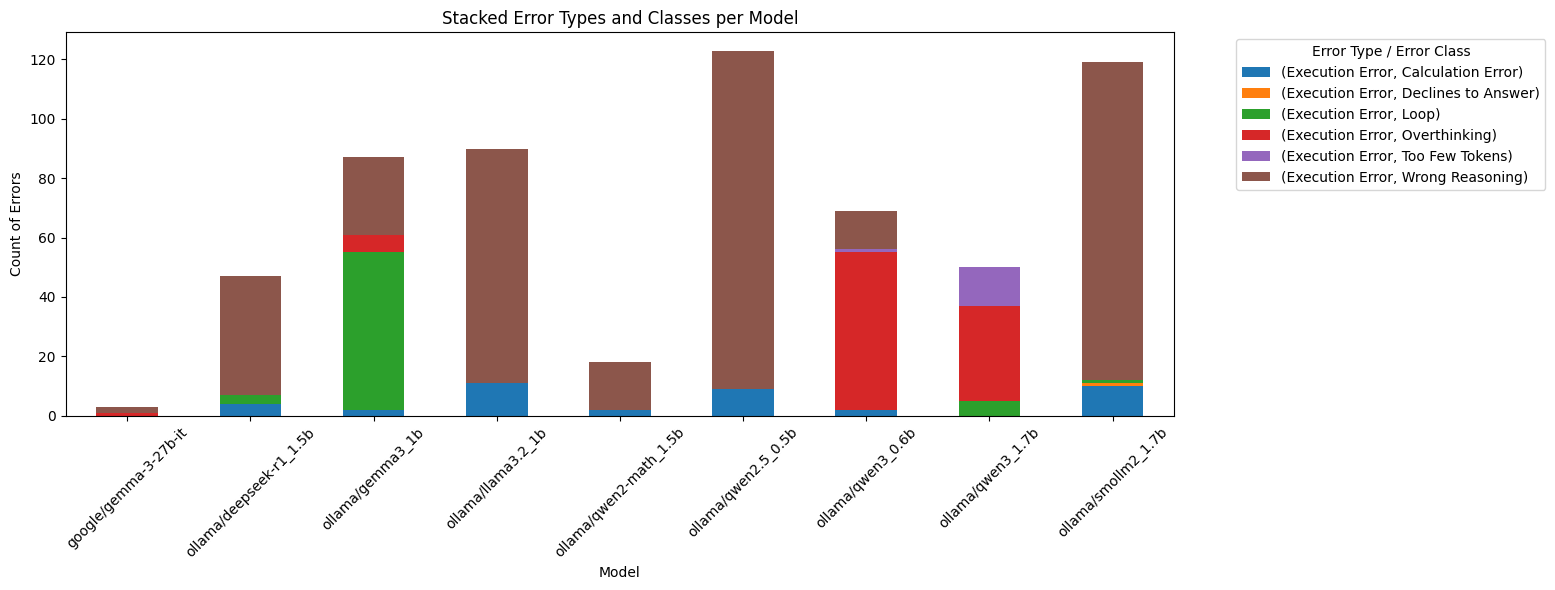

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Set index to "Model" to prepare for plotting
df_plot = df_err.set_index("Model")

# Plot as stacked bar chart
df_plot.plot(kind="bar", stacked=True, figsize=(12, 6))

plt.ylabel("Count of Errors")
plt.title("Stacked Error Types and Classes per Model")
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend(title="Error Type / Error Class", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## Per Operation Type

In [19]:
# Filter df by unique ids and collect number of unique question types
def get_question_type_mapping():
    seen_ids = set()
    question_type_mapping = {}
    for _, row in df.iterrows():
        if row['ID'] not in seen_ids:
            seen_ids.add(row['ID'])
            if row['Type'] not in question_type_mapping:
                question_type_mapping[row['Type']] = 0
            question_type_mapping[row['Type']] += 1
    return question_type_mapping

question_type_mapping = get_question_type_mapping()

# Convert to a DataFrame for better visualization
question_type_df = pd.DataFrame(list(question_type_mapping.items()), columns=['Question Type', 'Count'])
question_type_df = question_type_df.sort_values(by='Count', ascending=False)
question_type_df

,Question Type,Count
0,Subtraction,153
3,Addition,55
1,Common-Division,44
2,Multiplication,32


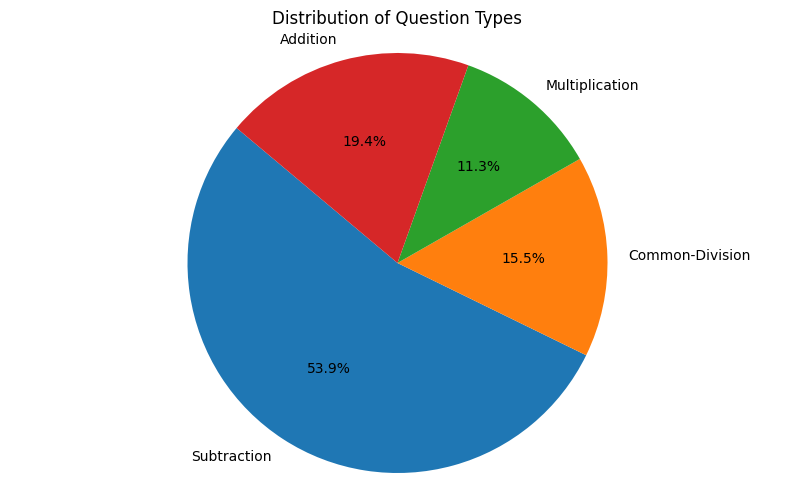

In [20]:
# Make a pie chart of the question types
import matplotlib.pyplot as plt
question_types = list(question_type_mapping.keys())
question_counts = list(question_type_mapping.values())
plt.figure(figsize=(10, 6))
plt.pie(question_counts, labels=question_types, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Question Types')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [1]:
qtypes_df = df.groupby(["Model", "Type"]).agg({
    "is_correct": "sum"
}).reset_index()

qtypes_df["Total_Questions"] = qtypes_df["Type"].map(lambda x: question_type_mapping.get(x, 0))
qtypes_df["Correct_Score"] = qtypes_df["is_correct"] / qtypes_df["Total_Questions"] * 100

# Pivot the DataFrame to get question types as rows and models as columns
qtypes_pivot = qtypes_df.pivot_table(index='Model', columns='Type', values='Correct_Score', fill_value=0)
qtypes_pivot

NameError: name 'df' is not defined

In [22]:
qtypes_dict = qtypes_pivot.to_dict()
significant_results = {}
for model, scores in qtypes_dict.items():
    items = list(scores.items())
    significant_results[model] = []
    for i in range(len(items)):
        for j in range(i + 1, len(items)):
            item1, item2 = items[i], items[j]
            p1 = item1[1]/100
            p2 = item2[1]/100
            n1 = question_type_mapping.get(item1[0], 0)
            n2 = question_type_mapping.get(item2[0], 0)
            if n1 == 0 or n2 == 0:
                raise ValueError(f"Question type '{item1[0]}' or '{item2[0]}' not found in mapping.")
            result = compare_accuracies_v3(p1, n1, p2, n2)
            if result.is_significant:
                significant_results[model].append((item1[0], item1[1], item2[0], item2[1], result.p_value, result.is_significant))

significant_results_df = pd.DataFrame([
    {
        'Model': model,
        'Type1': item[0],
        'Score1': item[1],
        'Type2': item[2],
        'Score2': item[3],
        'p_value': item[4],
        'is_significant': item[5]
    }
    for model, items in significant_results.items()
    for item in items
])
significant_results_df

,Model,Type1,Score1,Type2,Score2,p_value,is_significant
0,ollama/llama3.2_1b,Common-Division,75.000000,Multiplication,53.125000,0.046228,True
1,ollama/qwen2.5_0.5b,Addition,60.000000,Multiplication,37.500000,0.037415,True
2,ollama/qwen2.5_0.5b,Common-Division,65.909091,Multiplication,37.500000,0.010833,True
3,ollama/qwen2.5_0.5b,Multiplication,37.500000,Subtraction,56.862745,0.040434,True
4,ollama/smollm2_1.7b,Common-Division,72.727273,Multiplication,50.000000,0.040604,True
5,ollama/smollm2_1.7b,Common-Division,72.727273,Subtraction,55.555556,0.028184,True


Interpretation:

* **Qwen2.5:0.5B**: signifikant schlechtere Leistung bei Multiplikation
* **Llama 3.2 1B**: signifikant schlechtere Multiplikation als Division



## Question Type

In [12]:
# Different question types
def classify_question_type(question):
    if "how many more" in question.lower():
        return "How Many More"
    elif "how many" in question.lower():
        return "How Many"
    elif "how much" in question.lower():
        return "How Much"
    elif "how big" in question.lower():
        return "How Big"
    elif "how long" in question.lower():
        return "How Long"
    elif "what is" in question.lower():
        return "What is"
    elif "how deep" in question.lower():
        return "How Deep"
    elif "how far" in question.lower():
        return "How Far"
    return np.nan

df_qt = df.copy()
df_qt['Question_Type'] = df['Question-only'].apply(classify_question_type)
print("NAN Question Types:", df_qt['Question_Type'].isna().sum())

# show ten questions with NaN question types
for question in df_qt[df_qt['Question_Type'].isna()]['question']:
    print(question)

# Filter df by unique ids and collect number of unique question types
def get_question_type_mapping():
    seen_ids = set()
    question_type_mapping = {}
    for _, row in df_qt.iterrows():
        if row['ID'] not in seen_ids:
            seen_ids.add(row['ID'])
            if row['Question_Type'] not in question_type_mapping:
                question_type_mapping[row['Question_Type']] = 0
            question_type_mapping[row['Question_Type']] += 1
    return question_type_mapping

question_type_mapping = get_question_type_mapping()

question_type_df = pd.DataFrame(list(question_type_mapping.items()), columns=['Question Type', 'Count'])
question_type_df = question_type_df.sort_values(by='Count', ascending=False)
question_type_df

NAN Question Types: 0


,Question Type,Count
1,How Many,166
0,How Many More,75
2,How Much,33
3,How Big,3
4,What is,2
5,How Long,2
7,How Far,2
6,How Deep,1


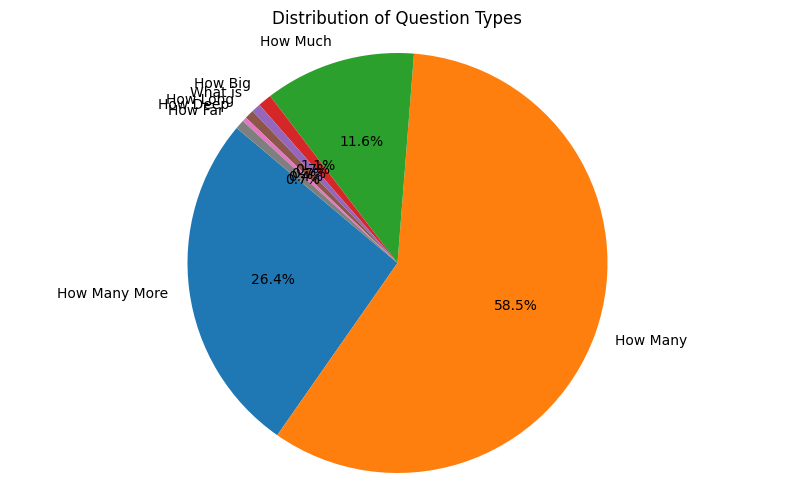

In [13]:
# Make a pie chart of the question types
import matplotlib.pyplot as plt
question_types = list(question_type_mapping.keys())
question_counts = list(question_type_mapping.values())
plt.figure(figsize=(10, 6))
plt.pie(question_counts, labels=question_types, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Question Types')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [14]:
qtypes_df = df_qt.groupby(["Model", "Question_Type"]).agg({
    "is_correct": "sum"
}).reset_index()

qtypes_df["Total_Questions"] = qtypes_df["Question_Type"].map(lambda x: question_type_mapping.get(x, 0))
qtypes_df["Correct_Score"] = qtypes_df["is_correct"] / qtypes_df["Total_Questions"] * 100
qtypes_pivot = qtypes_df.pivot_table(index='Question_Type', columns='Model', values='Correct_Score', fill_value=0)
qtypes_pivot

/var/folders/rl/3ygx2m4n1w747bxzh4qvfjs00000gn/T/ipykernel_62426/3781238049.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  qtypes_pivot = qtypes_df.pivot_table(index='Question_Type', columns='Model', values='Correct_Score', fill_value=0)


Model,google/gemma-3-27b-it,ollama/deepseek-r1_1.5b,ollama/gemma3_1b,ollama/llama3.2_1b,ollama/qwen2-math_1.5b,ollama/qwen2.5_0.5b,ollama/qwen3_0.6b,ollama/qwen3_1.7b,ollama/smollm2_1.7b
Question_Type,,,,,,,,,
How Big,100.000000,100.000000,100.000000,66.666667,100.000000,66.666667,66.666667,66.666667,66.666667
How Deep,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
How Far,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,50.000000,0.000000
How Long,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,50.000000
How Many,98.192771,87.951807,68.674699,70.481928,94.578313,57.831325,75.301205,83.132530,61.445783
How Many More,100.000000,76.000000,68.000000,64.000000,93.333333,48.000000,77.333333,82.666667,52.000000
How Much,100.000000,72.727273,66.666667,60.606061,87.878788,60.606061,69.696970,78.787879,54.545455
What is,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


In [16]:
qtypes_dict = qtypes_pivot.to_dict()
significant_results = {}
for model, scores in qtypes_dict.items():
    items = list(scores.items())
    significant_results[model] = []
    for i in range(len(items)):
        for j in range(i + 1, len(items)):
            item1, item2 = items[i], items[j]
            p1 = item1[1]/100
            p2 = item2[1]/100
            n1 = question_type_mapping.get(item1[0], 0)
            n2 = question_type_mapping.get(item2[0], 0)
            
            if n1 == 0 or n2 == 0:
                raise ValueError(f"Question type '{item1[0]}' or '{item2[0]}' not found in mapping.")
            result = compare_accuracies_v3(p1, n1, p2, n2)
            if result.is_significant:
                significant_results[model].append((item1[0], item1[1], item2[0], item2[1], result.p_value, result.is_significant))
                print(f"Comparing {p1} (n={n1}) with {p2} (n={n2}) for model {model}")

significant_results_df = pd.DataFrame([
    {
        'Model': model,
        'Type1': item[0],
        'Score1': item[1],
        'Type2': item[2],
        'Score2': item[3],
        'p_value': item[4],
        'is_significant': item[5]
    }
    for model, items in significant_results.items()
    for item in items
])
significant_results_df.head(10)

Comparing 0.8795180722891566 (n=166) with 0.76 (n=75) for model ollama/deepseek-r1_1.5b


,Model,Type1,Score1,Type2,Score2,p_value,is_significant
0,ollama/deepseek-r1_1.5b,How Many,87.951807,How Many More,76.0,0.03101,True


Interpretation

- **Deepseek**: Performs better on *How many* than on *how many more*